# RDU temperature: a first pass through the data

The main goal of this notebook is to explore the data and propose a simple data pipeline for the team while justifying some important decisions. I also want an initial gradient-boosting model to build on. This is an initial rough exploration aimed to guide decisions we make when we discuss.

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Works from the repo root or its notebooks/ folder.
DATA_PATH = Path('data/raw/rdu_asos_historical.csv')
if not DATA_PATH.exists():
    DATA_PATH = Path('../data/raw/rdu_asos_historical.csv')

## 1. What's in the file?

I start by checking the columns and identifying which ones could help us predict temperature. From an initial offline scan of the data, `M` is a missing-value marker. I'm also doing a first scan of missing data here.

In [2]:
raw = pd.read_csv(DATA_PATH, na_values=['M'], low_memory=False)
print(f'{len(raw):,} rows, {len(raw.columns)} columns')
print('Columns:', ', '.join(raw.columns))
display(raw[['station', 'valid', 'tmpf', 'dwpf', 'relh', 'sknt', 'mslp']].head())
display(raw.isna().mean().mul(100).round(2).rename('Missing (%)').to_frame())

56,495 rows, 32 columns
Columns: station, valid, lon, lat, tmpf, dwpf, relh, drct, sknt, p01i, alti, mslp, vsby, gust, skyc1, skyc2, skyc3, skyc4, skyl1, skyl2, skyl3, skyl4, wxcodes, ice_accretion_1hr, ice_accretion_3hr, ice_accretion_6hr, peak_wind_gust, peak_wind_drct, peak_wind_time, feel, metar, snowdepth


,station,valid,tmpf,dwpf,relh,sknt,mslp
0,RDU,2021-01-01 00:10,55.0,54.0,96.42,7.0,NaN
1,RDU,2021-01-01 00:23,55.0,54.0,96.42,9.0,NaN
2,RDU,2021-01-01 00:51,53.0,52.0,96.03,9.0,1025.0
3,RDU,2021-01-01 01:51,49.0,47.0,92.77,12.0,1026.3
4,RDU,2021-01-01 02:51,48.0,46.0,92.74,8.0,1026.4


,Missing (%)
station,0.00
valid,0.00
lon,0.00
lat,0.00
tmpf,0.01
dwpf,0.01
relh,0.02
drct,7.29
sknt,0.08
p01i,0.00


| Columns | Possible use | Choice for this first pass |
|---|---|---|
| `valid` | Observation time → hour, month, annual position | Use for calendar features |
| `tmpf` | Air temperature in °F; possibly past-temperature features | Prediction target; lags later |
| `dwpf`, `relh` | Dew point and relative humidity | Candidates for later historical features |
| `sknt`, `drct`, `mslp`, `alti` | Wind and pressure | Candidates for later historical features |
| `station`, `lat`, `lon` | Identify the observation location | Check station; fixed location adds no information here |
| `metar` | Original report, including timing clues | Retain for checking timestamps |
| Remaining columns | Clouds, precipitation, visibility, derived measures, etc. | Leave out of this first model |

Observed weather inside the forecast period is unavailable when we make the forecast. Even a strongly correlated column can't be used unless we know how to supply it for all 336 hours, though later we can explore how to fill those columns with predictions. For now I'll focus the checks (summary data, repeat data) on time and temperature, with a quick summary of a few possible later inputs.

In [3]:
data = raw.copy()
data['observation_time'] = pd.to_datetime(data['valid'], errors='coerce')
weather_columns = ['tmpf', 'dwpf', 'relh', 'sknt', 'mslp']
data[weather_columns] = data[weather_columns].apply(pd.to_numeric, errors='coerce')

display(pd.Series({
    'stations': ', '.join(data['station'].dropna().unique()),
    'first observation': data['observation_time'].min(),
    'last observation': data['observation_time'].max(),
    'unparsed timestamps': data['observation_time'].isna().sum(),
    'missing temperatures': data['tmpf'].isna().sum(),
    'exact duplicate rows': raw.duplicated().sum(),
    'repeated timestamps after first': data['observation_time'].duplicated().sum()
}, name='Check').to_frame())
display(data[weather_columns].describe().round(2))

repeated = data['observation_time'].duplicated(keep=False)
display(data.loc[repeated, ['valid', 'tmpf', 'metar']])

,Check
stations,RDU
first observation,2021-01-01 00:10:00
last observation,2026-09-16 23:51:00
unparsed timestamps,0
missing temperatures,8
exact duplicate rows,0
repeated timestamps after first,7


,tmpf,dwpf,relh,sknt,mslp
count,56487.00,56489.00,56485.00,56449.0,48952.00
mean,63.11,51.26,68.71,5.3,1017.65
std,16.50,17.69,20.87,4.0,6.37
min,10.00,-10.00,11.29,0.0,989.50
25%,51.00,38.00,52.19,3.0,1013.50
50%,66.00,55.00,71.64,5.0,1017.60
75%,76.00,66.00,87.14,8.0,1021.60
max,104.00,81.00,100.00,45.0,1042.90


,valid,tmpf,metar
8414,2021-11-07 01:51,50.0,KRDU 070551Z 03012KT 10SM BKN049 BKN090 OVC110...
8415,2021-11-07 01:51,50.0,KRDU 070651Z 03009KT 10SM OVC050 10/06 A3010 R...
18200,2022-11-06 01:51,70.0,KRDU 060551Z 16006KT 10SM SCT042 21/18 A3016 R...
18201,2022-11-06 01:51,69.0,KRDU 060651Z 16006KT 10SM FEW042 FEW140 21/18 ...
28139,2023-11-05 01:51,43.0,KRDU 050551Z 00000KT 10SM CLR 06/02 A3009 RMK ...
28140,2023-11-05 01:51,42.0,KRDU 050651Z 00000KT 10SM CLR 06/01 A3008 RMK ...
37991,2024-11-03 01:51,53.0,KRDU 030551Z 02003KT 10SM CLR 12/07 A3035 RMK ...
37992,2024-11-03 01:51,51.0,KRDU 030651Z 04004KT 10SM CLR 11/07 A3035 RMK ...
47990,2025-11-02 01:51,41.0,KRDU 020551Z 00000KT 10SM CLR 05/04 A3018 RMK ...
47991,2025-11-02 01:51,41.0,KRDU 020651Z 00000KT 10SM FEW055 05/04 A3017 R...


**Finding:** the data covers January 2021–September 16, 2026, at RDU. There are 8 missing temperatures, no exact duplicate rows, and 7 repeated timestamps after the first occurrence. 5 repeated times occur during the November daylight savings change. The other 2 are pairs of reports at the same time with different contents.

**Pipeline proposal:** parse missing markers and timestamps, preserve the original reports, and avoid dropping rows just because local times repeat. The two non-DST pairs occur outside `:51`, so they don't enter this first model. The shared pipeline may still need a rule for resolving reports at the same actual time, though I want to explore using GMT standard time (to avoid needing to handle DST) which is provided in the `metar` columns.

The temperature range is 10–104°F, which makes sense and indicates no extreme outliers caused by faulty sensors or something.

## 2. Defining hourly

The [ASOS guide](https://www.weather.gov/media/asos/aum-toc.pdf), sections 3.1.2–3.1.3, describes reported temperature as a five-minute average at the reporting time, not an average over the entire hour. We should double check what "hourly" means in regards to our project. For this first pass, I'll likely just use the `:51` recorded temperature. Here, I'll do some exploration, with the help of AI, on using UTC from `metar` instead of the EST time given in `valid` which I've relabeled `observation_time`.

### Check the timezone against the original reports

The CSV times have no timezone attached. Each METAR includes a `DDHHMMZ` token: day of month, hour, and minute in UTC. I compare it with the CSV time unchanged (UTC hypothesis), plus four hours (Eastern daylight time), and plus five hours (Eastern standard time). These are checks of this export, not a general METAR parser.

In [4]:
metar_time = data['metar'].str.extract(r'\b(\d{6})Z\b', expand=False)
matches = pd.DataFrame(index=data.index)
for hours in [0, 4, 5]:
    candidate = data['observation_time'] + pd.Timedelta(hours=hours)
    # Compare the day too, since converting to UTC can cross midnight/month-end.
    matches[hours] = candidate.dt.strftime('%d%H%M').eq(metar_time)
display(matches.sum().rename_axis('Hours added to CSV time').rename('Matching reports').to_frame())
print('Reports without exactly one match:', matches.sum(axis=1).ne(1).sum())
assert matches.sum(axis=1).eq(1).all(), 'Inspect unmatched or ambiguous reports.'
assert not matches[0].any(), 'Some reports may already be UTC; inspect before proceeding.'

# Select the offset supported by each report, then attach the UTC timezone.
offset = np.where(matches[4], 4, 5)
utc_clock = data['observation_time'] + pd.to_timedelta(offset, unit='h')
data['time_utc'] = utc_clock.dt.tz_localize('UTC')
data['time_local'] = data['time_utc'].dt.tz_convert('America/New_York')
# Check that the selected offset agrees with New York's actual DST rules.
assert data['time_local'].dt.tz_localize(None).eq(data['observation_time']).all()
print('All reconstructed UTC times convert back to the original Eastern local times.')

,Matching reports
Hours added to CSV time,
0,0
4,37381
5,19114


Reports without exactly one match: 0
All reconstructed UTC times convert back to the original Eastern local times.


**Finding:** all reports match a four- or five-hour offset, none match UTC directly, and converting back with `America/New_York` reproduces every original timestamp. This verifies Eastern local time for this file, including the seasonal offset changes.

### Can UTC simplify DST handling?

Yes. In autumn, local 01:51 occurs twice, once with offset `-04:00` and once with `-05:00`; these are different UTC hours. In spring, local 02:51 is skipped when the clock changes, but UTC still advances normally. Neither event should be treated as a bad report or a missing observation by itself.

Below I preserve both time representations and try an hourly UTC grid. Reindexing exposes genuinely absent routine reports without filling temperatures.

In [5]:
time_columns = ['observation_time', 'time_local', 'time_utc', 'tmpf']
fall_back = data['observation_time'].between('2024-11-03 00:00', '2024-11-03 03:59')
spring_forward = data['observation_time'].between('2024-03-10 00:00', '2024-03-10 04:59')
print('Fall: repeated local hour, distinct UTC hours')
display(data.loc[fall_back & data['observation_time'].dt.minute.eq(51), time_columns])
print('Spring: skipped local hour, consecutive UTC hours')
display(data.loc[spring_forward & data['observation_time'].dt.minute.eq(51), time_columns])

utc_reports = data.loc[data['observation_time'].dt.minute.eq(51)].set_index('time_utc').sort_index()
assert utc_reports.index.is_unique, 'Resolve reports at the same UTC instant before reindexing.'
utc_grid = pd.date_range(utc_reports.index.min(), utc_reports.index.max(), freq='h')
utc_temperature = utc_reports['tmpf'].reindex(utc_grid)
display(pd.Series({
    'Expected hourly slots': len(utc_grid),
    'Absent routine reports': len(utc_grid.difference(utc_reports.index)),
    'Present reports without temperature': utc_reports['tmpf'].isna().sum(),
    'Total missing target slots': utc_temperature.isna().sum()
}, name='UTC grid check').to_frame())

Fall: repeated local hour, distinct UTC hours


,observation_time,time_local,time_utc,tmpf
37990,2024-11-03 00:51:00,2024-11-03 00:51:00-04:00,2024-11-03 04:51:00+00:00,55.0
37991,2024-11-03 01:51:00,2024-11-03 01:51:00-04:00,2024-11-03 05:51:00+00:00,53.0
37992,2024-11-03 01:51:00,2024-11-03 01:51:00-05:00,2024-11-03 06:51:00+00:00,51.0
37993,2024-11-03 02:51:00,2024-11-03 02:51:00-05:00,2024-11-03 07:51:00+00:00,48.0
37994,2024-11-03 03:51:00,2024-11-03 03:51:00-05:00,2024-11-03 08:51:00+00:00,48.0


Spring: skipped local hour, consecutive UTC hours


,observation_time,time_local,time_utc,tmpf
31519,2024-03-10 00:51:00,2024-03-10 00:51:00-05:00,2024-03-10 05:51:00+00:00,55.0
31520,2024-03-10 01:51:00,2024-03-10 01:51:00-05:00,2024-03-10 06:51:00+00:00,55.0
31521,2024-03-10 03:51:00,2024-03-10 03:51:00-04:00,2024-03-10 07:51:00+00:00,55.0
31522,2024-03-10 04:51:00,2024-03-10 04:51:00-04:00,2024-03-10 08:51:00+00:00,54.0


,UTC grid check
Expected hourly slots,50039
Absent routine reports,74
Present reports without temperature,6
Total missing target slots,80


**Pipeline proposal:** use UTC for sorting, joins, hourly grids, and elapsed-hour lags; retain timezone-aware Eastern time for calendar features and readable output. The UTC grid has **74 absent routine reports plus six missing temperatures**, rather than counting DST clock changes as gaps. On this grid, `shift(1)` means one elapsed hour; `shift(24)` means 24 elapsed hours, which can differ from “the same local hour yesterday” across DST.

Do not mark the raw CSV as UTC with `utc=True`: that would mislabel local clock times. Localizing directly to `America/New_York` also needs an explicit choice for repeated autumn times; the METAR check resolves that choice here. The raw month/year supplies the date context that the METAR token alone lacks. See [pandas timezone handling](https://pandas.pydata.org/docs/user_guide/timeseries.html#time-zone-handling).

For the shared pipeline, define a local cutoff with `pd.Timestamp('2026-09-17', tz='America/New_York')`, then convert it to UTC with `.tz_convert('UTC')`. Derive local hour features by converting UTC timestamps back to Eastern. The calendar-only experiment below keeps its now-verified local timestamps for readability; its September window has no DST change. The UTC grid above is a working starting point for the later lag model, with gap filling still undecided.

In [6]:
display(data['observation_time'].dt.minute.value_counts().head(5)
        .rename_axis('Minute').rename('Reports').to_frame())

# Keep the routine report at its actual time, e.g. 02:51 stays 02:51.
routine = data.loc[data['observation_time'].dt.minute.eq(51),
                   ['observation_time', 'tmpf']].copy()
routine = routine.sort_values('observation_time').reset_index(drop=True)
display(routine.head())
print(f'Routine reports: {len(routine):,}')
print('Routine reports missing temperature:', routine['tmpf'].isna().sum())
print('Repeated local times retained:', routine['observation_time'].duplicated().sum())

,Reports
Minute,
51,49965
42,182
19,178
38,171
33,161


,observation_time,tmpf
0,2021-01-01 00:51:00,53.0
1,2021-01-01 01:51:00,49.0
2,2021-01-01 02:51:00,48.0
3,2021-01-01 03:51:00,45.0
4,2021-01-01 04:51:00,44.0


Routine reports: 49,965
Routine reports missing temperature: 6
Repeated local times retained: 5


**Working choice:** use routine `:51` reports at their recorded timestamps. A 02:51 reading could be a proxy for 03:00, but is not a measurement taken at 03:00. We need to confirm the project's description of how hourly is defined.

The checks above support Eastern local time and demonstrate an unambiguous UTC grid. Keep both fall-back readings. UTC solves clock ambiguity, but missing observations still need an agreed policy before lag features can be used.

Another potential option is to redownload the data but select UTC as the timezone instead of EST.

## 3. Choose a practice forecast period to explore

I'll pretend it's just before 9/17/25, and predict the next 14 days as a validation/first run through.

In [7]:
cutoff = pd.Timestamp('2025-09-17')
end = pd.Timestamp('2025-10-01')
train = routine.loc[routine['observation_time'] < cutoff].copy()
validation = routine.loc[(routine['observation_time'] >= cutoff) &
                         (routine['observation_time'] < end)].copy()

# This September window has no daylight-saving transition.
target_times = pd.date_range(cutoff + pd.Timedelta(minutes=51), periods=336, freq='h')
assert not validation['observation_time'].duplicated().any()
actual = validation.set_index('observation_time')['tmpf'].reindex(target_times)
print('Training observations with temperature:', train['tmpf'].notna().sum())
print('Practice targets:', len(target_times))
print('Available actual temperatures:', actual.notna().sum())
print('Missing validation targets:', actual.isna().sum())

Training observations with temperature: 41242
Practice targets: 336
Available actual temperatures: 334
Missing validation targets: 2


**Proposal:** make all 336 predictions from the same cutoff, and score every model on the same available observations. This window has 334 measured targets; two are missing. The team should share this split and scoring rule. We can also discuss using a different window as a test set (perhaps the 2 weeks before 9/17/26 so we can use more training data?).

## 4. Which patterns might be predictable?

I'll look at annual and daily cycles, then compare completed Septembers. Making sure the plots use only observations before the practice cutoff.

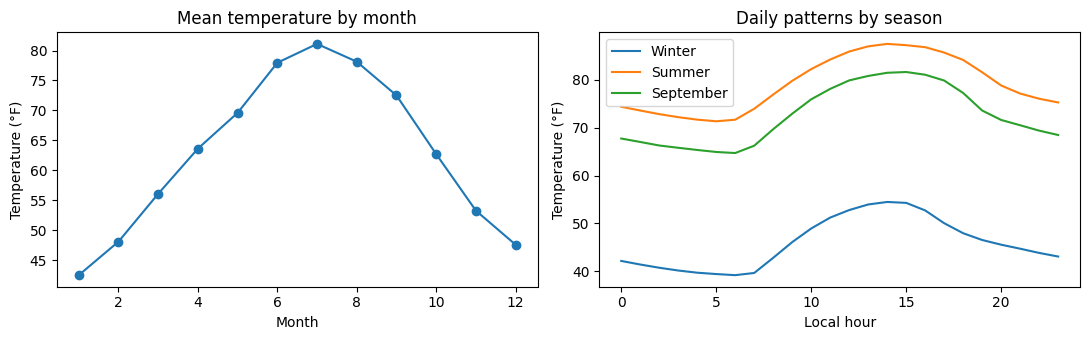

September stats:


,mean,min,max
year,,,
2021,72.6,50.0,92.0
2022,72.9,48.0,97.0
2023,73.0,54.0,100.0
2024,73.3,55.0,91.0


In [9]:
train['month'] = train['observation_time'].dt.month
train['hour'] = train['observation_time'].dt.hour
train['year'] = train['observation_time'].dt.year

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
train.groupby('month')['tmpf'].mean().plot(ax=axes[0], marker='o')
axes[0].set(title='Mean temperature by month', xlabel='Month', ylabel='Temperature (°F)')
for label, months in {'Winter': [12, 1, 2], 'Summer': [6, 7, 8], 'September': [9]}.items():
    cycle = train.loc[train['month'].isin(months)].groupby('hour')['tmpf'].mean()
    axes[1].plot(cycle.index, cycle.values, label=label)
axes[1].set(title='Daily patterns by season', xlabel='Local hour', ylabel='Temperature (°F)')
axes[1].legend()
plt.tight_layout()
plt.show()

september = train.loc[(train['month'] == 9) & (train['year'] < cutoff.year)]
print("September stats:")
display(september.groupby('year')['tmpf'].agg(['mean', 'min', 'max']).round(1))

**Finding:** As we intuitively expect, temperatures follow annual and daily cycles, and the daily curve changes with season. September also varies from year to year

**Feature decision:** start with hour and position in the year. Test whether a nonlinear model can learn their interaction

## 5. First feature set

 I'm adding a new feature to use sine/cosine pairs so that we can represent time cycles instead of having the model rely only on the raw number of the date/time. For the cycles, midnight is 1 and noon is 0 for cosine (so hour 23 would be closest to midnight because we're checking 23:51) and year-end is close to January. It seems like no scaling or fitted preprocessing is needed for gradient boosting since it's a tree model.

In [11]:
def calendar_features(times):
    times = pd.DatetimeIndex(times)
    hour = times.hour
    day = times.dayofyear
    days_in_year = np.where(times.is_leap_year, 366, 365)
    daily_angle = 2 * np.pi * (hour + times.minute / 60) / 24
    annual_angle = 2 * np.pi * (day - 1) / days_in_year
    return pd.DataFrame({
        'hour': hour, 'day_of_year': day,
        'hour_sin': np.sin(daily_angle), 'hour_cos': np.cos(daily_angle),
        'year_sin': np.sin(annual_angle), 'year_cos': np.cos(annual_angle)
    })

observed_train = train.dropna(subset=['tmpf'])
X_train = calendar_features(observed_train['observation_time'])
y_train = observed_train['tmpf'].to_numpy()
X_future = calendar_features(target_times)
display(X_train.head(24))

,hour,day_of_year,hour_sin,hour_cos,year_sin,year_cos
0,0,1,0.220697,0.975342,0.0,1.0
1,1,1,0.465615,0.884988,0.0,1.0
2,2,1,0.678801,0.734323,0.0,1.0
3,3,1,0.845728,0.533615,0.0,1.0
4,4,1,0.955020,0.296542,0.0,1.0
5,5,1,0.999229,0.039260,0.0,1.0
6,6,1,0.975342,-0.220697,0.0,1.0
7,7,1,0.884988,-0.465615,0.0,1.0
8,8,1,0.734323,-0.678801,0.0,1.0
9,9,1,0.533615,-0.845728,0.0,1.0


**Proposed experiment, not implemented here:** use predicted temperatures as future lag inputs. Train a model with past-temperature features, predict the first future hour from observed history, then feed that prediction into the next hour's features and repeat. This would be **recursive forecasting** that uses available information, but we should be careful since prediction errors can build up over 336 steps.

Before trying that, we should use the demonstrated UTC grid and define how to handle missing training lags. Validation must run recursively too; it cannot use actual temperatures from inside the forecast window.

## 6. Benchmarks and one gradient-boosting model

I'll use two simple comparisons for target values to evaluate the results of the gradient-boosting model: repeat September 16's 24-hour temperatures across the 336 hour window, and predict the training average for each month/hour combination. The second checks how much gradient-boosting improves beyond a typical seasonal pattern.

**Why try gradient boosting?** It combines small decision trees in sequence. With squared-error training, each new tree learns patterns in the remaining errors, and adds a small correction. A tree might split by season, then by hour. This lets the model learn different daily patterns in different parts of the year without manually specifying every interaction.

This is our alternative to linear regression and the time series based model we chose, Prophet.

I use scikit-learn's histogram version for a quick fit on tens of thousands of rows. The settings below are a starting point are just a starting point that should be tuned later. Early stopping is off to avoid a random internal validation split. [Model documentation](https://scikit-learn.org/stable/modules/ensemble.html#gradient-boosted-trees).

In [12]:
results = pd.DataFrame({'actual': actual}, index=target_times)

last_day_times = pd.date_range(cutoff - pd.Timedelta(days=1) + pd.Timedelta(minutes=51),
                               periods=24, freq='h')
last_day = train.set_index('observation_time')['tmpf']
# Select September first so repeated November local times do not affect reindexing.
last_day = last_day.loc[last_day.index >= cutoff - pd.Timedelta(days=1)]
last_day = last_day.reindex(last_day_times)
assert last_day.notna().all(), 'Choose an earlier complete day if the previous day has gaps.'
results['Repeat last day'] = np.tile(last_day.to_numpy(), 14)

seasonal_means = train.groupby(['month', 'hour'])['tmpf'].mean()
results['Month/hour average'] = [seasonal_means.loc[(t.month, t.hour)] for t in target_times]

model = HistGradientBoostingRegressor(
    max_iter=150, learning_rate=0.05, max_leaf_nodes=15,
    min_samples_leaf=50, l2_regularization=1.0,
    early_stopping=False, random_state=520
)
model.fit(X_train, y_train)
results['Gradient boosting'] = model.predict(X_future)

I use **MAE** as the main score: average absolute error in °F. RMSE puts more weight on large misses. R² compares with the validation mean and can be negative; that mean is a scoring reference, not a forecast available at the cutoff.

MASE can be added to shared evaluation once we agree on its denominator and hourly alignment. A proposed denominator is the training mean absolute difference between temperatures 24 elapsed hours apart. The UTC grid now makes those elapsed-hour pairs straightforward; I leave adding MASE to the shared evaluation step, after the team agrees on the definition.

In [13]:
model_names = ['Repeat last day', 'Month/hour average', 'Gradient boosting']
scored = results.dropna(subset=['actual'])
rows = []
for name in model_names:
    rows.append({
        'Model': name,
        'MAE (°F)': mean_absolute_error(scored['actual'], scored[name]),
        'RMSE (°F)': np.sqrt(mean_squared_error(scored['actual'], scored[name])),
        'R²': r2_score(scored['actual'], scored[name])
    })
metrics = pd.DataFrame(rows).set_index('Model').sort_values('MAE (°F)')
display(metrics.round(2))
print(f'Scored {len(scored)} of {len(results)} hours for every model.')

,MAE (°F),RMSE (°F),R²
Model,,,
Month/hour average,4.54,5.54,0.50
Gradient boosting,5.39,6.74,0.26
Repeat last day,7.87,9.74,-0.54


Scored 334 of 336 hours for every model.


**Finding:** month/hour average MAE = 4.54°F, boosting = 5.39°F, and repeating the last day = 7.87°F. The month/hour average performed best in this validation period. This is useful to keep as a comparison when improving the gradient-boosting model, since this first version doesn't outperform the simple month/hour average baseline yet.

## 7. Where does the first model miss?

I compare the forecast curves, then check the boosting model's errors by forecast day and hour. A positive signed error means the prediction is too warm.

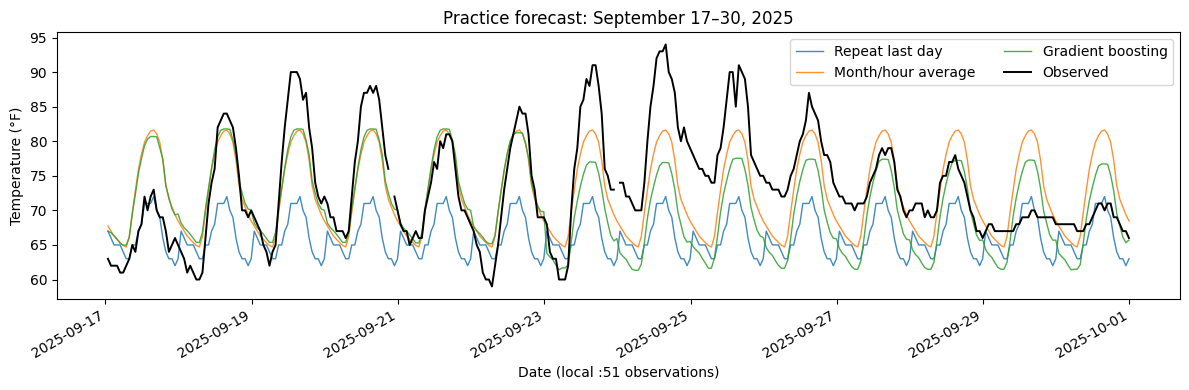

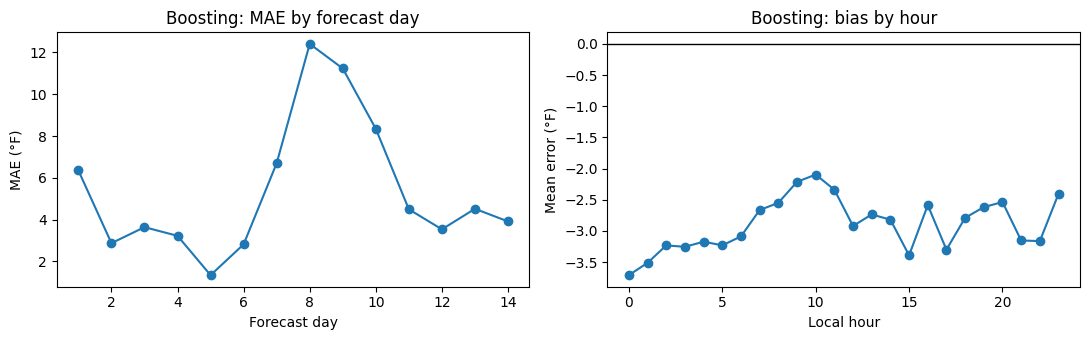

Mean signed error: -2.90°F


In [15]:
ax = results[model_names].plot(figsize=(12, 4), linewidth=1, alpha=0.85)
results['actual'].plot(ax=ax, color='black', linewidth=1.4, label='Observed')
ax.set(title='Practice forecast: September 17–30, 2025',
       xlabel='Date (local :51 observations)', ylabel='Temperature (°F)')
ax.legend(ncol=2)
plt.tight_layout()
plt.show()

errors = pd.DataFrame(index=results.index)
errors['signed'] = results['Gradient boosting'] - results['actual']
errors['absolute'] = errors['signed'].abs()
errors['forecast_day'] = np.arange(336) // 24 + 1
errors['hour'] = errors.index.hour

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
errors.groupby('forecast_day')['absolute'].mean().plot(ax=axes[0], marker='o')
axes[0].set(title='Boosting: MAE by forecast day', xlabel='Forecast day', ylabel='MAE (°F)')
errors.groupby('hour')['signed'].mean().plot(ax=axes[1], marker='o')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set(title='Boosting: bias by hour', xlabel='Local hour', ylabel='Mean error (°F)')
plt.tight_layout()
plt.show()
print(f'Mean signed error: {errors["signed"].mean():.2f}°F')

**Finding:** boosting's mean error is -2.90°F, so it is too cold on average in this window. Its largest daily MAE is on forecast day 8. The forecast repeats a regular daily shape but misses changes in the observed weather. This doesn't necessarily mean it's a persistent bias, but this is some evidence for a given period.

**Next decision:** There's a few more experiments to run that can inform our decisions. 
1. Check the same behavior in another time period before tuning. This can help us determine whether the same issues (losing to month/hour avg, too cold) persist.
2. Use a shorter training history as a simple first comparison. See if focusing only on more recent training data can produce a better result. Recent years could better represent current conditions, but we're trading that off with more data to learn seasonal patterns.
3. Later, we can use recursive lag features (temperature from the last hour as a potential feature, filling in our predictions for unavailable future data) to test whether recent conditions help early forecast days.

## 8. Initial findings and next decisions

This first pass supports a small calendar-based pipeline. The seasonal benchmark remains useful, and one validation window is not enough to pick a final model.

### Load
- **Proposal**: Keep raw CSV unchanged (unless pulling UTD based dataset instead); parse `M` as missing, time as datetime, and temperature as a number
- **Next step**: Write `load.py` in our pipeline, following these decisions

### Clean
- General
    - **Proposal**: Exclude missing targets from fit/score. Keep outliers.
    - **Why**: Filling the targets would change our evaluation. Temperature outliers are within reasonable range, which indicates no extreme data errors there
    - **Next step**: Write `clean.py` to store the same cleaned data to be use for all models
- Time
    - **Proposal**: Store UTC and use UTC as the main base for our time based features. Use the `:51` reports
    - **Why**: UTC makes time handling easier. We can convert to EST at the end.
    - **Next step**: confirm what "hourly" temperature refers to and continue the project based on that information
- Gaps in temperature data
    - **Proposal**: Keep every expected hour in the dataset and mark missing temperatures explicitly. Score only observed targets. We can experiment with interpolating missing temperature later
    - **Evidence**: 80 target gaps in dataset that we need to account for. The validation set I used originally had 334/336 available, maybe we should use a set that has all the temperature data
    - **Next step**: Before adding lag features, decide how to handle missing temperature inputs and whether calculation based on nearby observations can substitute
### Generate features
- **Proposal**: Start with hour and annual position to share across all models. Each model can experiment with adding its own features and share findings with the team. At the end we can consolidate all features in the feature generation step of the pipeline, and individual models can drop whatever columns they aren't using.
- **Why**: Visible/known daily and annual cycles that should be useful for each model. Our different models may perform better with different features, so after adding all features, we should drop any unused features.
- **Next step**: Build `generate_features.py` in our pipeline, starting with time based features. Later we can add more features as we experiment and evaluate.
### Validate
- **Proposal**: Use one fixed 14-day forecast to validate each model. Options to consider are the 14 days before 9/17/26, the same target dates 1 year earlier than our target dates, or another that comes up during discussion
- **Next step**: Agree on the windows and use it to write `validate.py`
### Model
- **Proposal**: Keep the simple benchmarks of repeating the last day in our training set and month/hour average to compare model results against. Use MAE. Each of us will experiment on our own model and use the same metrics/comparisons
- **Why**: Good info to prove our models are improving as we experiment
- **Next step**: Experiment on models once data pipeline is complete. 

### Other items of discussion
- Should we experiment with a shorter training history before we decide on the data split?
- Order of work:
    1. Agree on the discussion points above
    2. (If agree on shorter training data experiment) Run an experiment on if using less training data could be better
    3. Create shared pipeline code including load, clean, generate initial features, and validate.
    4. Experiment with features and tuning for our respective models.
    5. Final model evaluations/selections
    6. Refactor to include all features in data pipeline, which models can drop if necessary

This notebook is my starting point for the gradient boosting model. After discussion and settling our decisions, the team's linear regression and Prophet models should use the same targets, cutoff, and scoring rules, even if the features differ. Nothing in this notebook is final and is just a reference for alignment during our call. AI was used to help generate parts of this notebook.